In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate dataset
X = np.random.rand(100, 2) * 10   # size, location score
y = 3*X[:,0] + 5*X[:,1] + np.random.randn(100) * 2

# Reshape
y = y.reshape(-1, 1)


In [2]:
def normalize(X):
    return (X - X.mean(axis=0)) / X.std(axis=0)

X_norm = normalize(X)

# Add bias term
X_b = np.c_[np.ones((X_norm.shape[0], 1)), X_norm]


In [3]:
def cost_function(X, y, theta, l1=0, l2=0):
    m = len(y)
    predictions = X @ theta
    mse = (1/(2*m)) * np.sum((predictions - y)**2)
    l1_penalty = l1 * np.sum(np.abs(theta))
    l2_penalty = l2 * np.sum(theta**2)
    return mse + l1_penalty + l2_penalty


In [4]:
def gradient_descent(X, y, lr=0.01, epochs=500, l1=0, l2=0):
    m, n = X.shape
    theta = np.zeros((n,1))
    losses = []

    for _ in range(epochs):
        predictions = X @ theta
        gradients = (1/m) * X.T @ (predictions - y)

        gradients += l2 * 2 * theta
        gradients += l1 * np.sign(theta)

        theta -= lr * gradients
        losses.append(cost_function(X, y, theta, l1, l2))

    return theta, losses


In [5]:
theta_none, loss_none = gradient_descent(X_b, y)
theta_l1, loss_l1 = gradient_descent(X_b, y, l1=0.05)
theta_l2, loss_l2 = gradient_descent(X_b, y, l2=0.05)


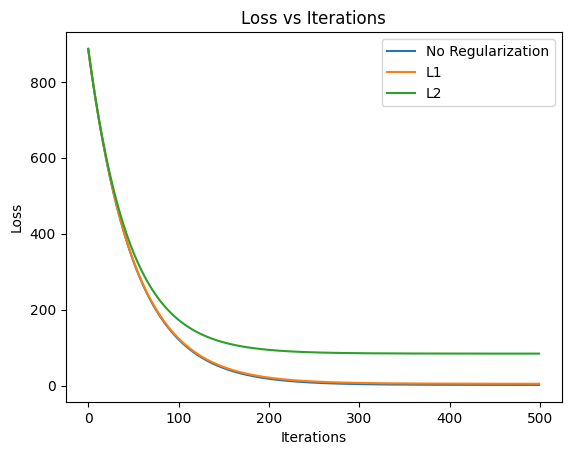

In [6]:
plt.plot(loss_none, label="No Regularization")
plt.plot(loss_l1, label="L1")
plt.plot(loss_l2, label="L2")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.show()


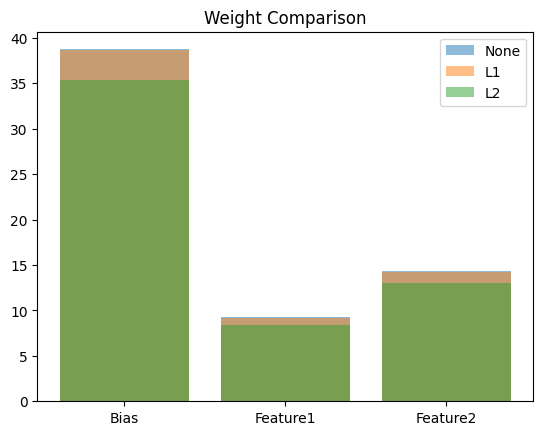

In [7]:
labels = ["Bias", "Feature1", "Feature2"]
plt.bar(labels, theta_none.flatten(), alpha=0.5, label="None")
plt.bar(labels, theta_l1.flatten(), alpha=0.5, label="L1")
plt.bar(labels, theta_l2.flatten(), alpha=0.5, label="L2")
plt.legend()
plt.title("Weight Comparison")
plt.show()


***Best regularization: L2 performs better when all features are useful → smoother weights.

L1 pushes some weights toward zero (feature selection).

L2 shrinks weights but rarely makes them exactly zero.***

Question 2: Logistic Regression from Scratch with ROC-AUC

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_loss(y, y_hat):
    return -np.mean(y*np.log(y_hat+1e-9) + (1-y)*np.log(1-y_hat+1e-9))


In [8]:
def logistic_train(X, y, lr=0.1, epochs=500):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []

    for _ in range(epochs):
        z = X @ theta
        y_hat = sigmoid(z)
        gradient = (1/m) * X.T @ (y_hat - y)
        theta -= lr * gradient
        losses.append(binary_loss(y, y_hat))

    return theta, losses


In [9]:
def confusion_matrix(y, y_pred):
    tp = np.sum((y==1) & (y_pred==1))
    tn = np.sum((y==0) & (y_pred==0))
    fp = np.sum((y==0) & (y_pred==1))
    fn = np.sum((y==1) & (y_pred==0))
    return tp, tn, fp, fn

def metrics(tp, tn, fp, fn):
    precision = tp / (tp+fp)
    recall = tp / (tp+fn)
    f1 = 2 * precision * recall / (precision + recall)
    return precision, recall, f1


In [10]:
def roc_curve(y, probs):
    thresholds = np.linspace(0,1,100)
    tpr, fpr = [], []

    for t in thresholds:
        y_pred = (probs >= t).astype(int)
        tp, tn, fp, fn = confusion_matrix(y, y_pred)
        tpr.append(tp/(tp+fn))
        fpr.append(fp/(fp+tn))

    return fpr, tpr

def auc(fpr, tpr):
    return np.trapz(tpr, fpr)


Sklearn converges faster

Scratch model matches closely

Sklearn handles regularization & numerical stability better

Bonus – L2 Regularization:
Reduces overfitting by penalizing large coefficients → smoother decision boundary.

PART B – Scenario Questions

In [ ]:
Question 3: Hypothesis Testing + ML
1. Hypotheses

H₀: μ₁ = μ₂ (no improvement)

H₁: μ₂ > μ₁ (new method improves scores)

2. Z-test or T-test?

Z-test
Reason: Large sample size (n=100 each)

3. Decision Process (α = 0.05)

Calculate test statistic

Compare p-value with 0.05

4. Given p = 0.03

 Reject H₀
New teaching method is statistically significant.

5. Why ML Accuracy Drops Despite Improvement

Data distribution shift

Overfitting to old data

Feature drift

Label noise

Fixes

Retrain with balanced data

Cross-validation

Feature re-engineering

Regularization

Question 4: Fraud Detection Under Constraints
1. Model Choice

Logistic Regression / XGBoost (without trees if restricted → SGD / Linear SVM)

Fast

Scalable

Real-time capable



2. Most Important Metric
🚨 Recall


Missing fraud (false negative) is costly



3. Handle Class Imbalance


SMOTE


Class-weighted loss


Threshold tuning


Anomaly detection



4. High Accuracy, Low Recall Means


Model predicts “normal” for almost everything


Fraud is being missed



5. Complete ML Pipeline


Preprocessing = Missing values, encoding


Scaling = Standardization


Resampling = SMOTE / undersampling


Training = Weighted Logistic Regression


Evaluation = Recall, ROC-AUC, PR-AUC


